# 66% Balanced Consensus: Fine-tuning BERT as a Financial Sentiment Classifier (Keras)
## 30 epochs with model checkpointing based on validation F1

## [See Weights and Biases Report](https://api.wandb.ai/links/iankelk/8b3mzk8t)

This document provides an explanation of the python script used to train a classifier on top of a BERT model via fine-tuning. The task is financial sentiment analysis, where sentences are classified into three sentiments: negative, neutral, and positive.

## Dataset

The dataset is [hosted on Hugging Face,](https://huggingface.co/datasets/takala/financial_phrasebank) where you can find further information on its curation, motivation, and annotation.

### Required dataset files

To run this notebook, you need the following four text files from the Financial PhraseBank dataset:

- `Sentences_AllAgree.txt`
- `Sentences_75Agree.txt`
- `Sentences_66Agree.txt`
- `Sentences_50Agree.txt`

**If you are running locally (Jupyter / VS Code):**

Place these four files in the **same folder** as this notebook so that paths like  
`"Sentences_66Agree.txt"` work directly. If you store them elsewhere, update the paths in the code accordingly.

**If you are running in Google Colab:**

1. Click the **folder icon** on the left to open the file browser.
2. Drag and drop the four files into the file browser (usually into `/content`).
3. Confirm that you can see:
   - `Sentences_AllAgree.txt`
   - `Sentences_75Agree.txt`
   - `Sentences_66Agree.txt`
   - `Sentences_50Agree.txt`  
   listed in the file panel before running the notebook.

### Overview

The dataset consists of 4846 lines, each containing a financial text sentence and its corresponding sentiment, separated by an '@' symbol. The sentiment can belong to one of three categories: Negative, Neutral, or Positive, and is distributed as:

- Neutral: 2879 entries (59%)
- Positive: 1363 entries (28%)
- Negative: 604 entries (12.4%)

### Data Fields

- **sentence**: A tokenized line from the dataset.
- **label**: A label representing the sentence class as a string: 'positive', 'negative', or 'neutral'.

### Data Splits

Although the dataset does not come with predefined training/validation/test splits, the sentences are categorized into different configurations based on the degree of agreement among the annotators:

- **sentences_50agree**: Number of instances with >= 50% annotator agreement - 4846 sentences
- **sentences_66agree**: Number of instances with >= 66% annotator agreement - 4217 sentences
- **sentences_75agree**: Number of instances with >= 75% annotator agreement - 3453 sentences
- **sentences_allagree**: Number of instances with 100% annotator agreement - 2264 sentences

For this project, we use the `sentences_50agree` configuration comprising of 4846 instances and manually split it into training, validation, and testing sets in a 70-15-15 proportion.

All sentences in the dataset are limited to fewer than 512 tokens, in accordance with the BERT model's input constraints.

## Imports and System Setup

The first part of the code includes importing necessary modules and setting up the TensorFlow environment to recognize accessible GPU devices.


## Metrics

The model's performance after training is evaluated based on accuracy and F1 score. Accuracy measures the proportion of correct predictions, while the F1 score provides a harmonic mean between precision and recall, hammered down for individual classes.

F1 score is calculated after each epoch by a custom F1_Evaluation class that uses the Scikit-learn function `f1_score()` for calculation.

We took the extra step of tracking the F1 score for the validation set for a few reasons due to using a financial dataset:

- **Handling Imbalance**: Financial datasets often exhibit class imbalance. For instance, genuine transactions significantly outnumber fraudulent ones. Accuracy can be misleading in such cases, making F1 a more balanced metric as it considers both precision and recall.

- **Balancing Costs**: Both false negatives (e.g., overlooking a negative sentiment) and false positives (e.g., misclassifying a neutral statement as negative) have implications. The F1 score ensures a balance between reducing these two error types.

- **Threshold Tuning**: Financial decisions can involve adjustable thresholds. The F1 score can guide optimization, ensuring neither precision nor recall is neglected.

## Wandb

[Wandb (Weights & Biases)](https://wandb.ai/site) is used for experiment tracking.

## Preprocessing

The data is read from the .txt file. The file encoding is first detected using the `chardet` library, and then the data is loaded into a pandas DataFrame using the detected encoding. The DataFrame contains two columns: sentence and label.

Then the data is split into train, validation, and test sets, stratifying on the label to respect the original distribution of classes in the dataset.

The `BertTokenizer` is used to encode the sentences into format suitable for the BERT model. `truncation=True` and `padding=True` ensures that all sequences are of the same length.

The tokenized sentence encodings and the corresponding labels are wrapped into TensorFlow's `Dataset` objects.

## Model Creation

The existing BERT model ('bert-base-uncased') from HuggingFace's transformer models is loaded for sequence classification with 3 labels (negative, neutral, positive).

## Model Compilation and Training

We compile the model with the Adam optimizer, SparseCategoricalCrossentropy loss, and accuracy as a metric. We use SparseCategoricalCrossentropy because this is a multi-class classification problem with three integer labels (negative, neutral, positive), not one-hot vectors. Concretely, for each input example the model outputs a length-3 vector of raw scores called logits, one score per class. The loss function then applies a softmax to those logits to turn them into a probability distribution over the three classes.

Given a true label $y \in {0,1,2}$ (encoded as a single integer, not a one-hot vector), the loss for that example is the negative log of the predicted probability assigned to class $y$. At inference time, we take the argmax of the logits (or of the softmax probabilities) to pick the predicted class: the index of the largest score corresponds to “negative”, “neutral”, or “positive” respectively.

A Wandb run is initialized, and the data is fit on the model using a batch size of 8 for 30 epochs. The validation data and the custom F1 score calculation callback are also passed in the fit method, as is early stopping.

## Evaluation

The model is evaluated on the test set. Classification report and F1 score are printed to show detailed information about performance on all three categories. The F1 score is also logged to the Wandb run.

In [ ]:
# Installation printed output removed
!pip install wandb

In [ ]:
# Installation printed output removed
!pip install transformers

In [ ]:
# Easy place to track what we're training
# Use the 66% consensus dataset
WHICH_DATASET = 'Sentences_66Agree.txt'
# Save our model checkpoints to
SAVE_PATH = "/content/drive/My Drive/finetuned_bert_66_30"

# Define the Weights & Biases run name
WHICH_RUN_NAME = f"bert_finetune_66_agree_{WHICH_DATASET.split('.')[0]}"

seed_val = 42

# Import necessary libraries
import os

# Used to suppress output for F1 validation calculation
import io
import contextlib

# For encoding detection
import chardet

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split

# Hugging Face Transformers for BERT
from transformers import BertTokenizer, TFBertForSequenceClassification

# Deep learning frameworks
import tensorflow as tf
import tf_keras as keras
from tf_keras import backend as K
from tf_keras.callbacks import EarlyStopping

# Ensure we have a GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Verify current GPU
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

# Weights and Biases for tracking experiments
import wandb
from wandb.integration.keras import WandbCallback

from google.colab import drive
drive.mount('/content/drive')


Num GPUs Available:  1
Found GPU at: /device:GPU:0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Prepare Data

## Overview

The varying levels of annotator agreements creates an unusual challenge. The aim is to create a train, test, and validation split that does not bias the model towards obvious sentiments. This guide will describe each step in the data splitting process.

## Step 1: Load the Data

Firstly we load the dataset files (which are text files in this case). Considering the possibility that these text files might have different encodings (they initially crashed the program as they use `ISO-8859-1`), we use Python's `chardet` library to detect the encoding before reading the file. This ensures that the loading of files doesn't fail due to encoding issues. The data is then shuffled randomly. The shuffling was an easy thing to miss, as previously we had used `train_test_split` from `scikit-learn` to split the data, and it had automatically shuffled the data. The data actually comes nearly sorted by sentiment, so without shuffling the model can't be fine-tuned at all.

The files are read in the following way:
- Every sentence in the dataset is separated by an '@' delimiter.
- There are no headers in the files so they are assigned later as ['sentence', 'label'].
- We use pandas' `read_csv` function to read these files.

## Step 2: Create a Subset from 'sentences_50agree'

The `sentences_50agree` dataset is the largest and most diverse dataset. To avoid overfitting and create a diverse validation set, we create a subset from this dataframe that will later be used for validation/testing. This subset is the same size as the train set.

## Step 3: Split the Subset into Validation and Test Sets

The subset created from `sentences_50agree` is split into validation and test sets. Here, a stratified sampling is performed to ensure that the split datasets have instances of each class ('positive', 'negative', and 'neutral') in proportions close to their original distribution in the parent dataset. The dataset is split in such way that 31% data is used for validation/testing. We choose 31% as this seems to result in the closest to a 70/15/15 train/validate/test split once the datasets have been assembled.

**Rationale for the 70/15/15 Split:**

We specifically chose a 70/15/15 split over other common splits (like 80/10/10) due to class imbalance. The 'Negative' class constitutes only ~12% of the dataset. A smaller test set (e.g., 10%) would result in only ~50 negative examples. This is too small a sample size to reliably evaluate the model's performance (F1 score) on that specific class, as a few misclassifications could drastically swing the metrics. The 15% split ensures we have a statistically significant number of examples (approx. 80) for the minority class in both validation and test sets, providing a more stable evaluation.

## Step 4: Update the Training Set

After obtaining the validation and test sets, we remove sentences present in these sets from the training set. This is done to avoid data leakage and ensure that the model doesn't see any sentence in the training phase that it would later encounter in the validation/testing phase.

## Step 5: Further Divide the Validation and Test Sets

The validation/test set subset is then divided equally into two parts: one part forms the validation set and the other part forms the test set.

## Step 6: Output the Sizes and Percentages

Finally, after creating all the datasets, we output the sizes of the train, validation, and test datasets along with their respective percentages to make sure that the classes are as balanced as they can be given the data.

This completes our data splitting process ensuring that we have a good mix of data in each dataset and our model does not get biased towards the easy-to-identify financial sentiments.

In [ ]:
# Load a dataset given its path
def load_data(data_path, seed):
    raw_data = open(data_path, 'rb').read()
    result = chardet.detect(raw_data)
    encoding = result['encoding']
    print("Encoding for:", data_path, "is:", encoding)
    df = pd.read_csv(data_path, delimiter='@', header=None, names=['sentence', 'label'], encoding=encoding)
    return df.sample(frac=1, random_state=seed)

# Load data with correct encoding and delimiter
df_50agree = load_data('Sentences_50Agree.txt', seed_val)
train = load_data(WHICH_DATASET, seed_val)

# Save original count for unit testing purposes
original_50agree_count = train.shape[0]

# Take a random subset of sentences_50agree equal in size to the size of train dataset
subset_50agree = df_50agree.sample(n=len(train), random_state=seed_val)

# Randomly choose 31% of the data from this subset for validation/test
_, valid_test_subset = train_test_split(subset_50agree, test_size=0.31, random_state=seed_val, stratify=subset_50agree['label'])

# Remove items from train dataset that are in the validation/test set
train = train[~train['sentence'].isin(valid_test_subset['sentence'])]

# Split the validation/test set in half into validation and test set
valid, test = train_test_split(valid_test_subset, test_size=0.5, random_state=seed_val, stratify=valid_test_subset['label'])

# Load pre-trained BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Convert texts to BERT input format
train_encodings = tokenizer(train.sentence.tolist(), truncation=True, padding=True)
val_encodings = tokenizer(valid.sentence.tolist(), truncation=True, padding=True)
test_encodings = tokenizer(test.sentence.tolist(), truncation=True, padding=True)

def make_tf_dataset(encodings, labels):
    """Function to convert encodings and labels into tensorflow dataset."""
    input_ids = np.array(encodings['input_ids'])
    attention_mask = np.array(encodings['attention_mask'])
    labels = np.array(labels)
    return tf.data.Dataset.from_tensor_slices((input_ids, attention_mask, labels)).map(
        lambda input_ids, attention_mask, labels : ({"input_ids": input_ids, "attention_mask": attention_mask}, labels))

# Defining the labels keys and their respective values as per the model
label2num = {'negative':0,'neutral':1,'positive':2}
train_labels = [label2num[x] for x in train.label.tolist()]
val_labels = [label2num[x] for x in valid.label.tolist()]
test_labels = [label2num[x] for x in test.label.tolist()]

# Convert encodings and labels into tensorflow dataset
train_dataset = make_tf_dataset(train_encodings, train_labels)
val_dataset = make_tf_dataset(val_encodings, val_labels)
test_dataset = make_tf_dataset(test_encodings, test_labels)

# Print the sizes and percentages
total_size = len(train) + len(valid) + len(test)

print("\nSize of Train set:", len(train),
      f"({(len(train)/total_size)*100:.2f}%)")
print("Size of Validation set:", len(valid),
      f"({(len(valid)/total_size)*100:.2f}%)")
print("Size of Test set:", len(test),
      f"({(len(test)/total_size)*100:.2f}%)")

Encoding for: Sentences_50Agree.txt is: ISO-8859-1
Encoding for: Sentences_66Agree.txt is: ISO-8859-1

Size of Train set: 3084 (70.22%)
Size of Validation set: 654 (14.89%)
Size of Test set: 654 (14.89%)


# Check out the distribution of the classes to ensure they look balanced across datasets

In [ ]:
# Distribution in the Training set
print("Training set:")
print(train['label'].value_counts())

# Distribution in the Validation set
print("\nValidation set:")
print(valid['label'].value_counts())

# Distribution in the Test set
print("\nTest set:")
print(test['label'].value_counts())

Training set:
label
neutral     1854
positive     852
negative     378
Name: count, dtype: int64

Validation set:
label
neutral     388
positive    186
negative     80
Name: count, dtype: int64

Test set:
label
neutral     388
positive    185
negative     81
Name: count, dtype: int64


# F1 Callback to track F1 Validation

In [ ]:
# Custom callback that:
# 1. Computes a weighted F1 score on a held-out validation dataset
# 2. Saves the best model (by F1)
# 3. Logs F1 to Weights & Biases
# 4. Exposes F1 via `logs` so other callbacks (e.g. EarlyStopping) can monitor it
class F1_Evaluation(keras.callbacks.Callback):
    def __init__(self, validation_data=(), interval=1, save_path=SAVE_PATH):
        """
        Parameters
        ----------
        validation_data : tf.data.Dataset
            Validation dataset yielding (inputs, labels) batches.
        interval : int
            How often to compute F1 (in epochs). interval=1 means every epoch.
        save_path : str
            Where to save the best model weights via `model.save_pretrained`.
        """
        super(F1_Evaluation, self).__init__()

        # Track the best F1 score we have seen so far across epochs
        self.best_f1_so_far = 0.0
        self.save_path = save_path
        self.interval = interval
        self.dataset = validation_data

        # We pre-materialize the entire validation set into memory so that:
        # - we do not need to re-iterate over a potentially stateful dataset each epoch
        # - we can call `model.predict` on plain batches of inputs
        self.X_val, self.y_val = [], []

        # Iterate once over the validation dataset to collect input and label batches
        for batch in self.dataset:
            # Each batch is a tuple of (inputs, labels)
            inputs, labels = batch

            # `inputs` is a dict with keys like ["input_ids", "attention_mask"]
            self.X_val.append(inputs)

            # Convert label tensor to a 1D NumPy array, even if there is a single label
            # 1. `labels.numpy()` -> NumPy
            # 2. `np.squeeze` removes singleton dimensions
            # 3. `np.atleast_1d` guarantees it is at least 1D
            self.y_val.append(np.atleast_1d(np.squeeze(labels.numpy())))

        # Keep a history of F1 scores across epochs (for later analysis / plotting)
        self.f1_scores = []

    def on_epoch_end(self, epoch, logs=None):
        """
        Called by Keras at the end of each epoch.
        We compute F1 on the pre-saved validation set and:
        - update `self.best_f1_so_far` and save the model if it improved
        - log F1 to W&B
        - inject `val_f1_score` into `logs` so that EarlyStopping can monitor it
        """
        # Always work with a dict (Keras passes one in, but we keep this defensive)
        if logs is None:
            logs = {}

        print("\nCalculating validation F1 score...")

        # Only compute F1 on epochs that match the specified interval
        # (e.g., every epoch if interval=1, every 2 epochs if interval=2, etc.)
        if epoch % self.interval == 0:
            y_pred = []

            # Loop over the cached validation batches and get predictions
            for X_val_batch in self.X_val:
                # Suppress verbose output from `model.predict` for cleaner logs
                with contextlib.redirect_stdout(io.StringIO()), \
                     contextlib.redirect_stderr(io.StringIO()):
                    # For a Hugging Face TF model, `.predict` returns an object
                    # with a `.logits` attribute
                    y_pred_single = self.model.predict(X_val_batch).logits

                # Convert logits to probabilities with softmax, then take argmax
                # to get the predicted class index for each example
                y_pred_single = tf.nn.softmax(y_pred_single).numpy().argmax(axis=-1)

                # Again, make sure each batch prediction is at least 1D before stacking
                y_pred.append(np.atleast_1d(y_pred_single))

            # Concatenate all batch predictions and labels into flat arrays
            y_pred = np.concatenate(y_pred)
            y_val = np.concatenate(self.y_val)

            # Compute weighted F1 score to account for possible class imbalance
            _f1 = f1_score(y_val, y_pred, average='weighted')

            # If this epoch's F1 is the best so far, update our record and save the model
            if _f1 > self.best_f1_so_far:
                self.best_f1_so_far = _f1
                print("Found new best F1 score:", _f1, "Saving the model.")
                # For HF models, `save_pretrained` saves the weights + config
                self.model.save_pretrained(self.save_path)

            # Store F1 in the callback's internal history
            self.f1_scores.append(_f1)

            # Human-readable printout to the notebook
            print("Epoch: {} - validation_data f1_score: {:.4f}".format(epoch + 1, _f1))

            # Make F1 available to other callbacks (e.g., EarlyStopping) via `logs`.
            # EarlyStopping can now use `monitor="val_f1_score", mode="max"`.
            logs["val_f1_score"] = _f1

            # Log to Weights & Biases so we can track F1 over time in the UI
            wandb.log({"val_f1_score": _f1})


In [ ]:
# Log in to W&B account for experiment tracking
wandb.login()

# Load pre-trained BERT model with a classification layer on top
# Added use_safetensors=False to address TypeError: 'builtins.safe_open' object is not iterable
model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3, use_safetensors=False)

# Define loss function, optimizer, and metrics
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Learning-rate schedule: start with a small LR and decay it exponentially over time.
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=3e-5,  # initial LR (good start for BERT fine-tuning)
    decay_steps=10000,           # after this many "steps" (batches), apply one decay
    decay_rate=0.9               # multiply the LR by 0.9 every `decay_steps`
)

# Adam optimizer that uses the schedule above instead of a fixed learning rate.
optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

# Compile the model (tell Keras how to train it)
model.compile(
    optimizer=optimizer,   # optimization algorithm (Adam with the LR schedule)
    loss=loss_fn,          # loss function to minimize (sparse categorical crossentropy)
    metrics=['accuracy']   # metrics to report during training/validation (classification accuracy)
)

# Initializing wandb run
wandb.init(project="bert-sentiment", name=WHICH_RUN_NAME)

# Prepare for F1 score evaluation
val_dataset_temp = val_dataset.batch(8)
f1_evaluation = F1_Evaluation(validation_data=val_dataset_temp, interval=1, save_path=SAVE_PATH)


# Add early stopping
early_stopping = EarlyStopping(monitor='val_f1_score', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    train_dataset.batch(8),
    validation_data=val_dataset_temp,
    epochs=30,
    callbacks=[WandbCallback(save_model=False), f1_evaluation, early_stopping]
)


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.
All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/30
386/386 [==============================] - ETA: 0s - loss: 0.4859 - accuracy: 0.8077
Calculating validation F1 score...
Found new best F1 score: 0.8339223972891564 Saving the model.
Epoch: 1 - validation_data f1_score: 0.8339
386/386 [==============================] - 119s 162ms/step - loss: 0.4859 - accuracy: 0.8077 - val_loss: 0.4061 - val_accuracy: 0.8364 - val_f1_score: 0.8339
Epoch 2/30
386/386 [==============================] - ETA: 0s - loss: 0.1959 - accuracy: 0.9316
Calculating validation F1 score...
Epoch: 2 - validation_data f1_score: 0.8292
386/386 [==============================] - 32s 83ms/step - loss: 0.1959 - accuracy: 0.9316 - val_loss: 0.4975 - val_accuracy: 0.8257 - val_f1_score: 0.8292
Epoch 3/30
386/386 [==============================] - ETA: 0s - loss: 0.0980 - accuracy: 0.9663
Calculating validation F1 score...
Found new best F1 score: 0.8481737746639952 Saving the model.
Epoch: 3 - validation_data f1_score: 0.8482
386/386 [============================

# Plot the training

In [ ]:
def plot_training_process(history, f1_scores):
    fig, axs = plt.subplots(2, 2, figsize=(18, 8),
                            gridspec_kw={'height_ratios': [2, 1]})

    # Collapse the subplots for the F1 scores into a single subplot
    axs[1, 0].remove()
    axs[1, 1].remove()

    # Plotting training and validation loss
    axs[0, 0].plot(history.history["loss"], label='Train')
    axs[0, 0].plot(history.history["val_loss"], label='Validation')
    axs[0, 0].set_title("Model Loss")
    axs[0, 0].set_ylabel("Loss")
    axs[0, 0].set_xlabel("Epoch")
    axs[0, 0].legend()

    # Plotting training and validation accuracy
    axs[0, 1].plot(history.history["accuracy"], label='Train')
    if "val_accuracy" in history.history:
        axs[0, 1].plot(history.history["val_accuracy"], label='Validation')
    axs[0, 1].set_title("Model Accuracy")
    axs[0, 1].set_ylabel("Accuracy")
    axs[0, 1].set_xlabel("Epoch")
    axs[0, 1].legend()

    # Plotting Validation F1 Scores
    ax2 = fig.add_subplot(2, 1, 2)  # 2x1, occupying the second slot.
    ax2.plot(f1_scores)
    ax2.set_title("Validation F1 Score")
    ax2.set_ylabel("F1 Score")
    ax2.set_xlabel("Epoch")
    ax2.legend(["F1 Score"], loc="upper left")

    # Improve layout and show plots
    plt.subplots_adjust(hspace=0.6)
    plt.show()

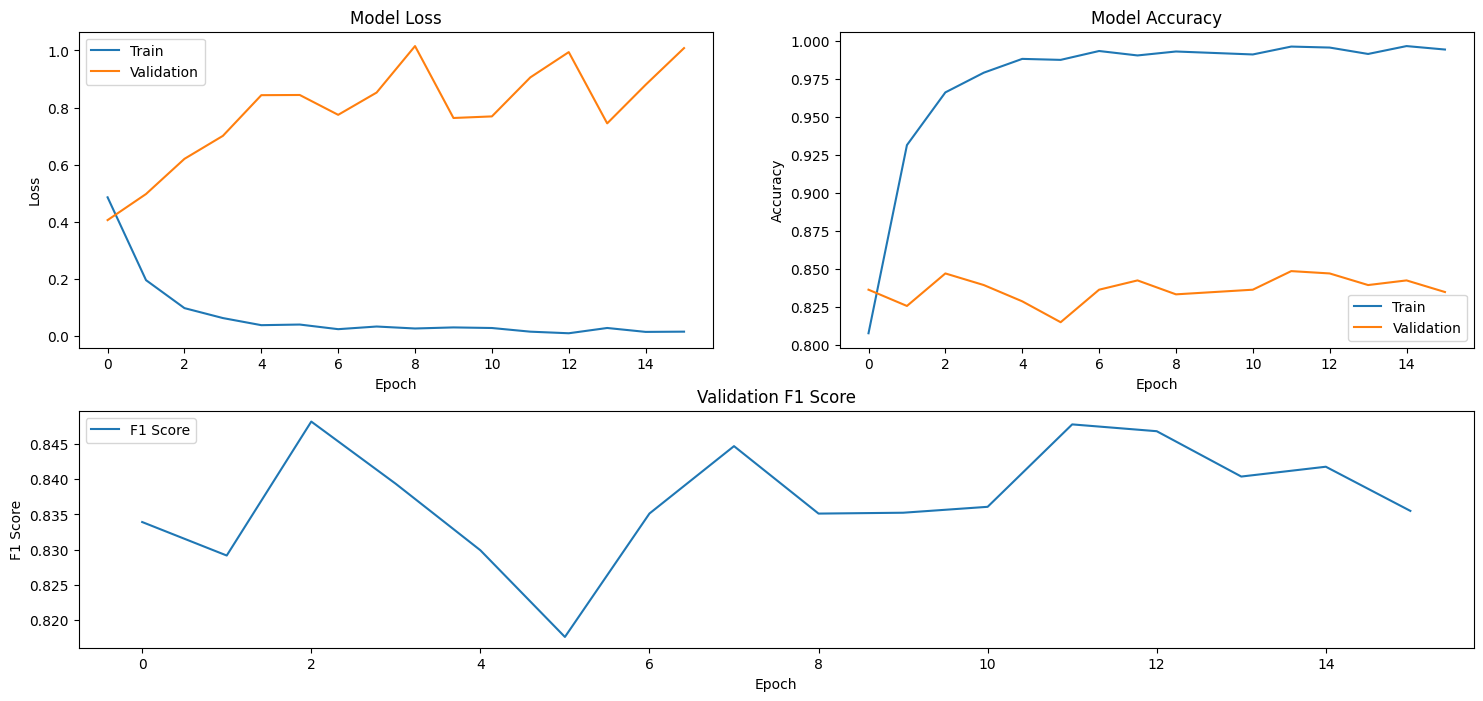

In [ ]:
plot_training_process(history, f1_evaluation.f1_scores)

# Evaluate with the test data on the checkpointed model

In [ ]:
# Load the checkpointed model
finetuned_model = TFBertForSequenceClassification.from_pretrained(SAVE_PATH)
finetuned_model.trainable = False

# Evaluate the model with test dataset and show the classification report
y_test = test.label.map(label2num).values
y_pred = tf.nn.softmax(finetuned_model.predict(test_dataset.batch(8)).logits).numpy().argmax(axis=-1)

print(classification_report(y_test, y_pred, target_names=['negative', 'neutral', 'positive']))
test_f1_score = f1_score(y_test, y_pred, average='weighted')
print("Test F1 Score:", test_f1_score)

# Log the test F1 score to wandb (single data point)
wandb.log({'test_f1_score': test_f1_score})

Some layers from the model checkpoint at /content/drive/My Drive/finetuned_bert_66_30 were not used when initializing TFBertForSequenceClassification: ['dropout_113']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at /content/drive/My Drive/finetuned_bert_66_30.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


82/82 [==============================] - 5s 23ms/step
              precision    recall  f1-score   support

    negative       0.82      0.83      0.82        81
     neutral       0.90      0.83      0.86       388
    positive       0.72      0.82      0.77       185

    accuracy                           0.83       654
   macro avg       0.81      0.83      0.82       654
weighted avg       0.84      0.83      0.83       654

Test F1 Score: 0.8307986768501189
